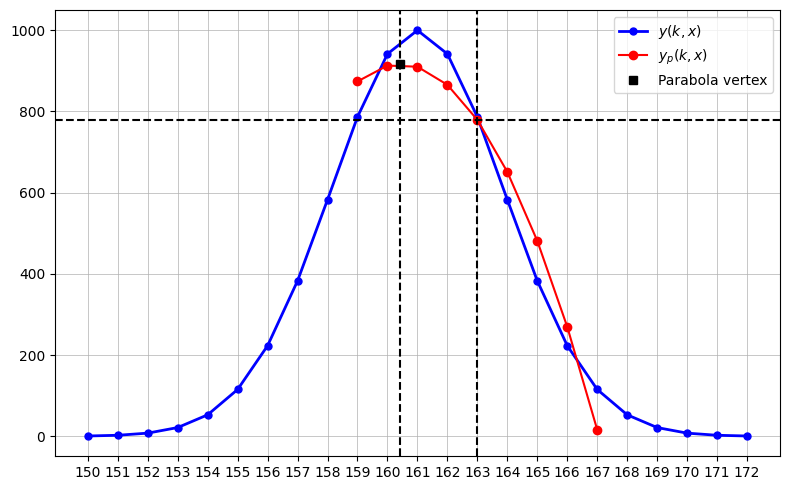

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
n = 4                  # Mitad de la ventana
degree = 2             # Grado del polinomio
k_index = 13           # Índice del punto de interés (ajusta para centrar/descentrar)

# Señal sintética tipo bump
x_full = np.linspace(150, 172, 23)
y_full = np.exp(-0.06 * (x_full - 161)**2) * 1000  # Bump gaussiano

# Ventana local
x_neigh = np.arange(-n, n + 1)                          # [-3, -2, -1, 0, 1, 2, 3]
x_local = x_neigh + x_full[k_index]                     # Coordenadas vecinas centradas en k
y_local = y_full[k_index - n : k_index + n + 1]         # Valores originales en vecindario

# Ajuste parabólico local
coeffs = np.polyfit(x_neigh, y_local, degree)           # Ajuste en coordenadas relativas
p = np.poly1d(coeffs)                                   # Polinomio resultante
y_local_poly = p(x_neigh)                               # Valores de la parábola en los vecinos

# Evaluar la parábola suavemente para graficar
x_fine = np.linspace(-n, n, 200)
y_fine = p(x_fine)

# Vértice de la parábola
a, b, c = coeffs
x_vertex = x_full[k_index] - b / (2 * a)
y_vertex = p(-b / (2 * a))

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(x_full, y_full, 'o-', label=r'$y(k,x)$', color='blue', linewidth=2, markersize=5)
plt.plot(x_local, y_local_poly, 'ro-', label='$y_p(k,x)$', markersize=6)
# plt.plot(x_fine + x_full[k_index], y_fine, 'r-', label=r'$p(k,x)$ (fit)', linewidth=2)
plt.plot(x_vertex, y_vertex, 'ks', label='Parabola vertex', markersize=6)

# Líneas auxiliares
plt.axvline(x=x_full[k_index], linestyle='--', color='black', linewidth=1.5)
plt.axvline(x=x_vertex, linestyle='--', color='black', linewidth=1.5)
plt.axhline(y=c, linestyle='--', color='black', linewidth=1.5)

# Estética
# plt.xlabel('Pixel', fontsize=12)
# plt.ylabel('Intensity', fontsize=12)
# plt.title('SG Polynomial Fit with Neighborhood on Parabola', fontsize=14)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linewidth=0.5)
plt.xticks(x_full.astype(int), fontsize=10)  # Forzar ticks en cada pixel, enteros
plt.yticks(fontsize=10)
plt.tight_layout()

# Mostrar o guardar
plt.show()
# plt.savefig("sg_parabola_points_on_fit.png", dpi=300)
# plt.savefig("sg_parabola_points_on_fit.pdf")
